In [1]:
import matplotlib.pyplot as plt
plt.style.use('thesis')
import numpy as np

In [2]:
base = '/avatar/vmehta/sfh_500_10bins_20260427_112623/finalmodel/train_sfh_1100_6bins_20260423_112538_snr100__test_sfh_500_10bins_20260427_112623_snr100'
wavs = np.load('/home/vmehta/honours-project/code/data/wavelengths.npy')
spec6 = np.load('/home/vmehta/honours-project/code/data/sfh_sixbins_spectra.npy')
spec10 = np.load('/home/vmehta/honours-project/code/data/sfh_tenbins_spectra.npy')
pred = np.load(f'{base}_pred.npy')
true = np.load(f'{base}_true.npy')

In [30]:
def moving_average(x, w):
        """Returns the moving average of the input array."""
        return np.convolve(x, np.ones(w), 'same') / w

def normalize(v):
    s_flat = v / moving_average(v, 100)
    return s_flat * moving_average(np.ones_like(s_flat), 100)  # dealing with edges

norm6 = [normalize(spec) for spec in spec6]
norm10 = [normalize(spec) for spec in spec10]

pred_spec = pred @ norm6
true_spec = true @ norm10
residual = pred_spec - true_spec

In [31]:
young = []
mixed = []
old = []

for n, i in enumerate(true):
    if np.sum(i[-2:]) > 0.5:
        old.append(n)
    elif np.sum(i[:4]) > 0.5:
        young.append(n)
    else:
        mixed.append(n)

In [32]:
edges6 = np.log10(np.r_[np.array([0.1])*1e6, np.logspace(7, 10.15, 6)])
centers6 = (edges6[:-1] + edges6[1:]) / 2
widths6 = edges6[1:] - edges6[:-1]
edges10 = np.log10(np.r_[np.array([0.1])*1e6, np.logspace(7, 10.15, 10)])
centers10 = (edges10[:-1] + edges10[1:]) / 2
widths10 = edges10[1:] - edges10[:-1]

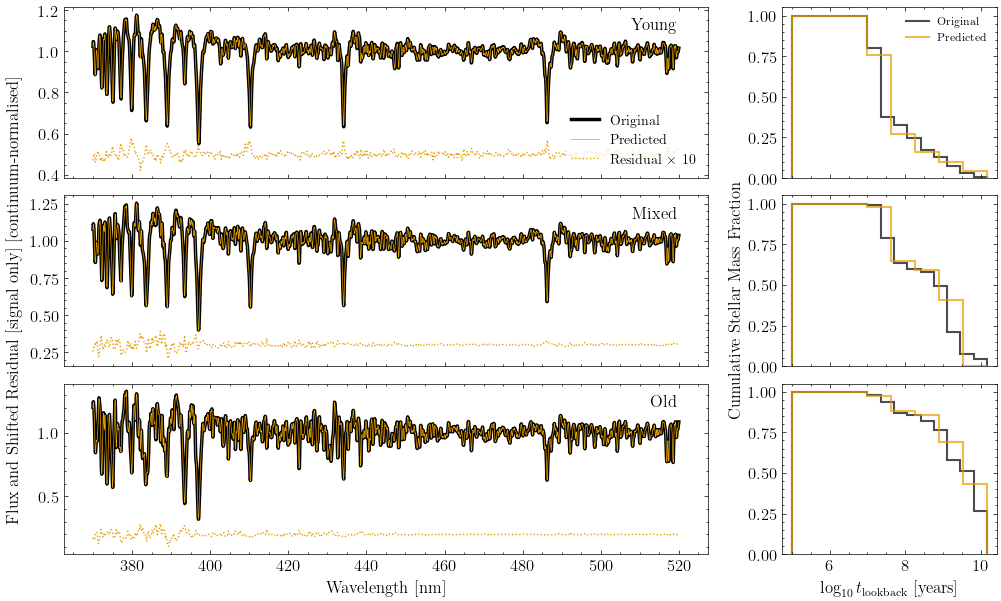

In [33]:
a = 59
b = 32
c = 183

fig, ax = plt.subplots(3, 2, figsize=(10, 6), sharex='col', constrained_layout=True, gridspec_kw={'width_ratios': [3, 1], 'wspace': 0.08})

ax[0, 0].plot(wavs/10, true_spec[a], 'k', linewidth=2.5, label='Original')
ax[0, 0].plot(wavs/10, pred_spec[a], 'C0', linewidth=0.5, label='Predicted')
ax[0, 0].plot(wavs/10, residual[a]*10 + 0.5, 'C0:', linewidth=1, label='Residual $\\times$ 10')
ax[0, 0].legend(fontsize=10, loc='lower right', frameon=True, edgecolor='white', facecolor='white', framealpha=0.8)
ax[0,0].text(0.95, 0.85, 'Young', transform=ax[0, 0].transAxes, fontsize=12, fontweight='bold', ha='right', va='bottom')

ax[0, 1].stairs(np.flip(np.cumsum(np.flip(true[a]))), edges10, color='k', alpha=0.7, linewidth=1.5, label='Original')
ax[0, 1].stairs(np.flip(np.cumsum(np.flip(pred[a]))), edges6, color='C0', alpha=0.7, linewidth=1.5, label='Predicted')
ax[0, 1].legend(fontsize=8, loc='upper right')

ax[1, 0].plot(wavs/10, true_spec[b], 'k', linewidth=2.5, label='Original')
ax[1, 0].plot(wavs/10, pred_spec[b], 'C0', linewidth=0.5, label='Predicted')
ax[1, 0].plot(wavs/10, residual[b]*10 + 0.3, 'C0:', linewidth=1, label='Residual $\\times$ 10')
ax[1, 0].text(0.95, 0.85, 'Mixed', transform=ax[1, 0].transAxes, fontsize=12, fontweight='bold', ha='right', va='bottom')

ax[1, 1].stairs(np.flip(np.cumsum(np.flip(true[b]))), edges10, color='k', alpha=0.7, linewidth=1.5, label='Original')
ax[1, 1].stairs(np.flip(np.cumsum(np.flip(pred[b]))), edges6, color='C0', alpha=0.7, linewidth=1.5, label='Predicted')

ax[2, 0].plot(wavs/10, true_spec[c], 'k', linewidth=2.5, label='Original')
ax[2, 0].plot(wavs/10, pred_spec[c], 'C0', linewidth=0.5, label='Predicted')
ax[2, 0].plot(wavs/10, residual[c]*10 + 0.2, 'C0:', linewidth=1, label='Residual')
ax[2, 0].text(0.95, 0.85, 'Old', transform=ax[2, 0].transAxes, fontsize=12, fontweight='bold', ha='right', va='bottom')
ax[2, 0].set_xlabel('Wavelength [nm]', fontsize=12)

ax[2, 1].stairs(np.flip(np.cumsum(np.flip(true[c]))), edges10, color='k', alpha=0.7, linewidth=1.5, label='Original')
ax[2, 1].stairs(np.flip(np.cumsum(np.flip(pred[c]))), edges6, color='C0', alpha=0.7, linewidth=1.5, label='Predicted')
ax[2, 1].set_xlabel(f'$\\log_{{10}}t_\\mathrm{{lookback}}$ [years]', fontsize=12)

fig.supylabel('Flux and Shifted Residual [signal only] [continuum-normalised]', fontsize=12)
fig.text(0.735, 0.5, 'Cumulative Stellar Mass Fraction', va='center', ha='center', rotation='vertical', fontsize=12)

plt.savefig('/home/vmehta/honours-project/thesis/figures/mismatched.pdf', format='pdf')
plt.show()

Text(0, 0.5, 'Flux [arbitrary units]')

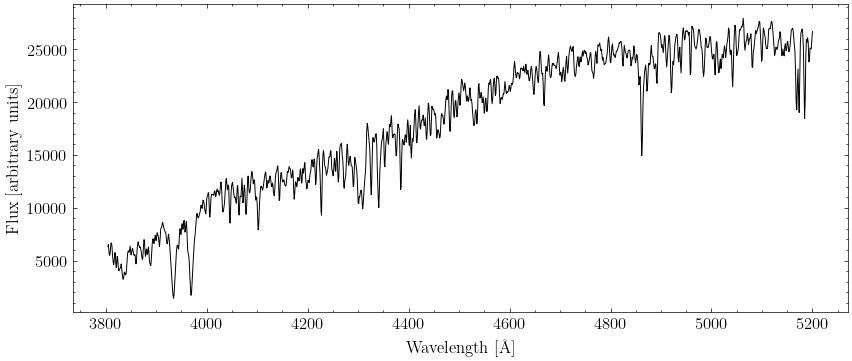

In [8]:
# trying a real spectrum just for fun

from astropy.io import fits

with fits.open('/home/vmehta/honours-project/code/data/spec-3000-54843-0423.fits') as f:
    header = f[0]
    coadd = f["COADD"].data
    wav = 10**coadd['loglam'][:1358]
    flux = coadd['flux'][:1358]
    ivar = coadd['ivar'][:1358]
    model = coadd['model'][:1358]

plt.figure(figsize=(10, 4))
plt.plot(wav, flux, 'k', linewidth=0.7)
plt.xlabel('Wavelength [Å]', fontsize=12)
plt.ylabel('Flux [arbitrary units]', fontsize=12)

In [9]:
header.header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
TAI     =        4738479553.20 / 1st row Number of seconds since Nov 17 1858    
RA      =            164.86011 / 1st row RA of telescope boresight (deg)        
DEC     =            40.369628 / 1st row Dec of telescope boresight (degrees)   
EQUINOX =              2000.00 /                                                
RADECSYS= 'FK5     '           /                                                
TAIHMS  = '12:02:28.94'        / 1st row TAI time HH:MM:SS.SS                   
TIMESYS = 'tai     '           / TAI, not UTC                                   
MJD     =                54843 / MJD of observation                             
MJDLIST = '54843   '        

In [10]:
def moving_average(x, w):
    """Returns the moving average of the input array."""
    return np.convolve(x, np.ones(w), 'same') / w

window = 100
continuum = moving_average(flux, window)

# Continuum-normalised flux.
s_flat = flux / continuum
edge_factor = moving_average(np.ones_like(flux), window)
final_s = s_flat * edge_factor

# Propagate uncertainties consistently: if flux is scaled by 'scale', ivar scales as 1/scale^2.
scale = edge_factor / continuum
ivar_final = ivar / (scale ** 2)

contmodel = moving_average(model, window)
s_flat_model = model / contmodel
final_model = s_flat_model * moving_average(np.ones_like(model), window)

Text(0, 0.5, 'Continuum-normalised Flux [arbitrary units]')

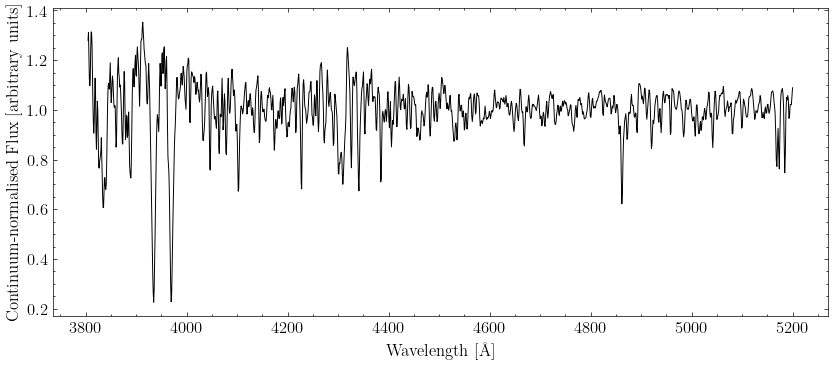

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(wav, final_s, 'k', linewidth=0.7)
plt.xlabel('Wavelength [Å]', fontsize=12)
plt.ylabel('Continuum-normalised Flux [arbitrary units]', fontsize=12)

In [12]:
import sys
from pathlib import Path

# Ensure the project src directory is importable in this notebook kernel.
src_root = Path('/home/vmehta/honours-project/code/src')
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from AnniesLasso.thecannon.vectorizer.polynomial import PolynomialVectorizer
from AnniesLasso.thecannon.model import CannonModel


In [13]:
base = '/avatar/vmehta/sfh_1100_6bins_20260423_112538/sfh_1100_6bins_20260423_112538'
new_wavs = np.load(f'{base}_wavelength.npy')[116:]
new_spec = np.load(f'{base}_snr100_spectra.npy')[:, 116:]
new_ivar = np.load(f'{base}_snr100_invvar.npy')[:, 116:]
train_labels = fits.getdata(f'{base}_labels.fits')

In [14]:
from scipy.interpolate import interp1d

# Keep a consistent name with your request.
s_final = final_s

# Interpolate continuum-normalized spectrum onto the model wavelength grid.
valid = np.isfinite(wav) & np.isfinite(s_final)
source_wav = wav[valid]
source_flux = s_final[valid]

order = np.argsort(source_wav)
source_wav = source_wav[order]
source_flux = source_flux[order]

flux_interp = interp1d(
    source_wav,
    source_flux,
    kind='linear',
    bounds_error=False,
    fill_value=1.0
)
s_final_on_target = flux_interp(new_wavs)

# Interpolate the propagated, continuum-normalised ivar.
ivar_valid = np.isfinite(wav) & np.isfinite(ivar_final)
ivar_source_wav = wav[ivar_valid]
ivar_source = ivar_final[ivar_valid]

ivar_order = np.argsort(ivar_source_wav)
ivar_source_wav = ivar_source_wav[ivar_order]
ivar_source = ivar_source[ivar_order]

ivar_interp = interp1d(
    ivar_source_wav,
    ivar_source,
    kind='linear',
    bounds_error=False,
    fill_value=0.0
)
ivar_on_target = ivar_interp(new_wavs)

model_interp = interp1d(
    wav,
    final_model,
    kind='linear',
    bounds_error=False,
    fill_value=1.0
)
model_on_target = model_interp(new_wavs)

In [15]:
print(s_final_on_target)

[1.         1.30740443 1.22114546 ... 1.03177224 1.05816062 1.08319247]


In [16]:
lspace = ["1", "2", "3", "4", "5", "6"]
vectorizer = PolynomialVectorizer(lspace, 2)
model = CannonModel(train_labels, new_spec, new_ivar,
					   vectorizer=vectorizer, dispersion=new_wavs)

In [17]:
model.train()
labels, *_ = model.test(s_final_on_target, ivar_on_target)

2026-04-28 15:39:58,419 [INFO] Training 6-label CannonModel with 1100 stars and 1551 pixels/star
stty: 'standard input'2026-04-28 15:39:58,428 [DEBUG] Couldn't get screen size. Progressbar may look odd.


[                                                                                                    ]   0% (1/1551)                          

: Inappropriate ioctl for device


[=======================================================================================================] 100% (152s)                               


stty: 'standard input'2026-04-28 15:42:30,111 [DEBUG] Couldn't get screen size. Progressbar may look odd.
: Inappropriate ioctl for device
2026-04-28 15:42:30,111 [INFO] Running test step on 1 spectra


[=                                                                                                   ] 100% (0s)                         


In [18]:
norm_new = []
for i in norm6:
    norm_new.append(i[116:])

norm_new

[array([1.02953168, 1.0365669 , 1.03657864, ..., 0.98281539, 0.98576944,
        0.99303783], shape=(1551,)),
 array([1.03781629, 1.06116712, 1.06870282, ..., 1.00024308, 1.00571981,
        1.0124543 ], shape=(1551,)),
 array([1.01120635, 1.06256468, 1.09781807, ..., 1.00160791, 1.00767648,
        1.01744936], shape=(1551,)),
 array([1.03344618, 1.08536142, 1.11738804, ..., 0.99798713, 1.00249377,
        1.01758511], shape=(1551,)),
 array([1.1660359 , 1.19488566, 1.17629319, ..., 1.0289471 , 1.05096931,
        1.07286673], shape=(1551,)),
 array([1.3101362 , 1.3328433 , 1.28857565, ..., 1.08264071, 1.11989981,
        1.14649595], shape=(1551,))]

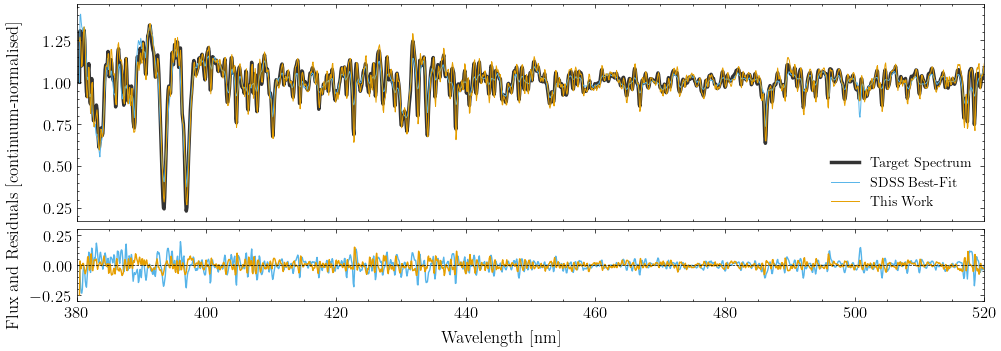

In [19]:
fig, ax = plt.subplots(2, 1, figsize=(10, 3.5), gridspec_kw={'height_ratios': [3, 1]}, constrained_layout=True, sharex=True)

ax[0].plot(new_wavs/10, s_final_on_target, 'k', alpha=0.8, linewidth=2.5, label='Target Spectrum')
ax[0].plot(new_wavs/10, model_on_target, 'C1', linewidth=0.7, label='SDSS Best-Fit')
ax[0].plot(new_wavs/10, (labels @ norm_new)[0], 'C0', linewidth=0.7, label='This Work')
ax[0].set_xlim(380, 520)
ax[0].legend(loc='lower right', fontsize=10)

ax[1].plot(new_wavs/10, s_final_on_target - model_on_target, 'C1', linewidth=1)
ax[1].plot(new_wavs/10, s_final_on_target - (labels @ norm_new)[0], 'C0', linewidth=1)
ax[1].axhline(0, color='k', linestyle='--', linewidth=0.5)
ax[1].set_ylim(-0.3, 0.3)

fig.supylabel('Flux and Residuals [continuum-normalised]', fontsize=12)
fig.supxlabel('Wavelength [nm]', fontsize=12)

plt.savefig('/home/vmehta/honours-project/thesis/figures/sdss-test.pdf', format='pdf')
plt.show()


In [20]:
sdss_stats = np.array([
    np.mean(s_final_on_target - model_on_target),
    np.std(s_final_on_target - model_on_target)
])

model_stats = np.array([
    np.mean(s_final_on_target - (labels @ norm_new)[0]),
    np.std(s_final_on_target - (labels @ norm_new)[0])
])

print("SDSS Residuals: Mean =", sdss_stats[0], ", Std Dev =", sdss_stats[1])
print("Model Residuals: Mean =", model_stats[0], ", Std Dev =", model_stats[1])

SDSS Residuals: Mean = 0.0001866991256688437 , Std Dev = 0.049578386672410206
Model Residuals: Mean = -0.00011417655992783099 , Std Dev = 0.03174305007224256


In [21]:
labels

array([[2.83257936e-45, 0.00000000e+00, 2.34918884e-69, 0.00000000e+00,
        4.52912189e-01, 5.47087811e-01]])